In [1]:
# Studying a piece of land and analyzing the geography for use with irrigation

# Add the Python ArcGIS package to the default Anaconda packages that were installed during Navigator install
# !pip install arcgis

In [2]:
import arcgis
from arcgis.gis import GIS
# from arcgis.raster.functions import *
# from ipywidgets import *

C:\Users\Johanna\anaconda3\envs\py36\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


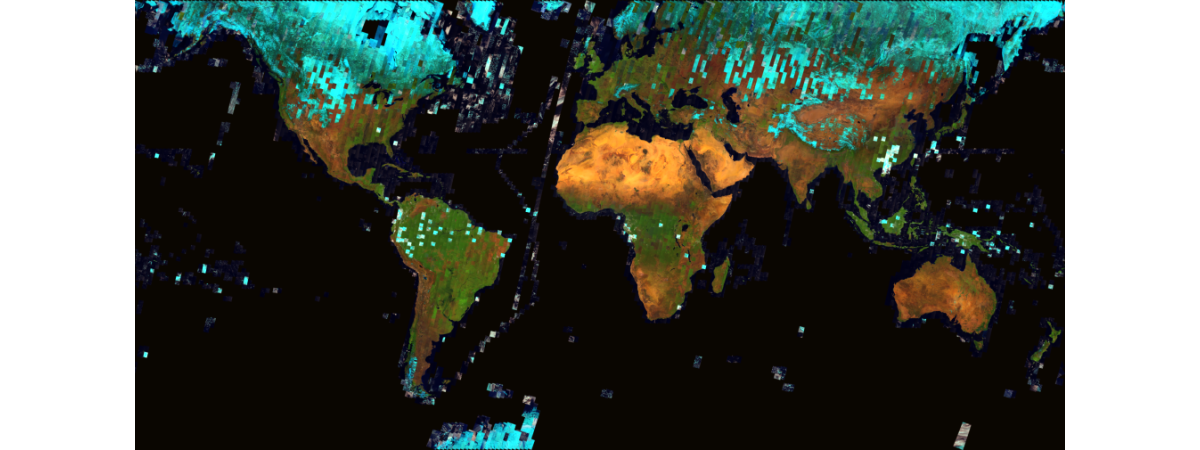

In [3]:
gis = GIS()

arcgis.raster.analytics.is_supported(gis)

search_item = gis.content.search('title:Multispectral Landsat', 'Imagery Layer', outside_org=True)[0]
landsat = search_item.layers[0]

landsat

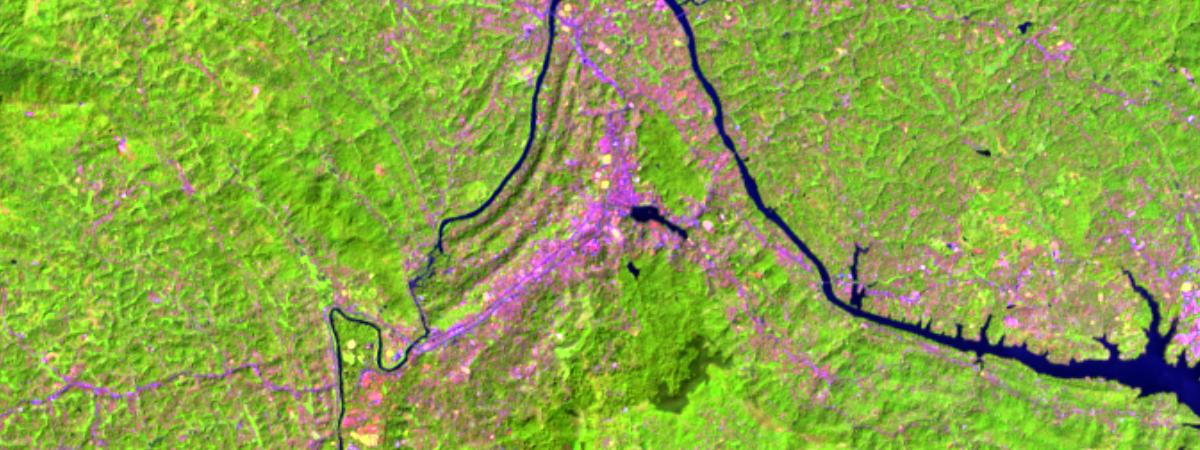

In [4]:
# Access ArcGIS online tools to get a satellite image of the Bangalore region

from arcgis.geocoding import geocode

extent = geocode("Kandi", "India", out_sr=landsat.properties.spatialReference)[1]
landsat.extent = extent['extent']
landsat

In [2]:
# Use the GMRT online mapping tool to get terrain for an area east of Bangalore
# https://www.gmrt.org/GMRTMapTool/

# Bangalore is centered at: [12.971599, 77.594566]
# So use bounds of [12.99, 77.59] and [13.01, 77.57]

# Save the terrain grid as ArcASCII File Format, and High Grid Resolution
# It downloads an .asc file with 39 columns and 35 rows

# Read in the terrain to a two-dimensional array:

import numpy as np

Terrain  = np.loadtxt("kandiactual.asc", skiprows=6)
Terrain.shape

(863, 328)

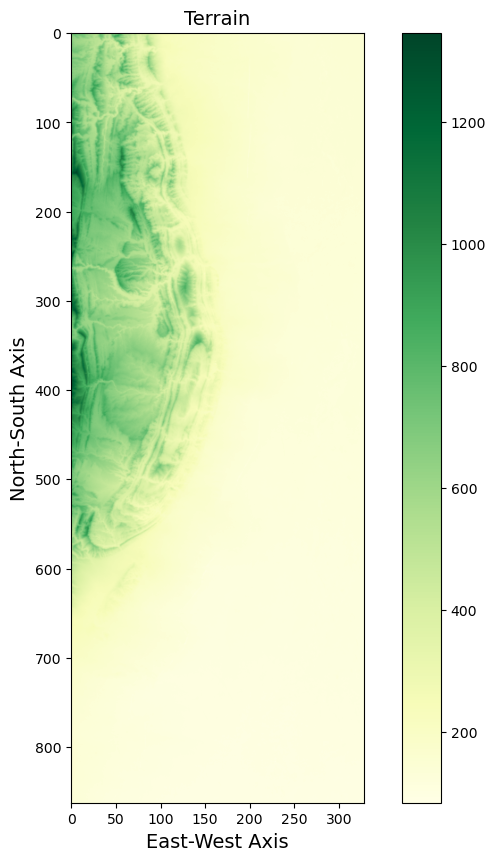

In [3]:
#Plot the terrain to see it visually

import matplotlib.pyplot as plt
from PIL import Image  #images processing package

def plot_terrain():
    #plot vegetation cover
    plt.figure(figsize=(10, 10))
    plt.imshow(Terrain)

    plt.xlabel('East-West Axis', fontsize=14)
    plt.ylabel('North-South Axis', fontsize=14)
    plt.title('Terrain', fontsize=14);
    plt.set_cmap("YlGn")
    plt.colorbar()
    
    plt.show()
        
plot_terrain()

In [5]:
# Set a uniform soil depth at all locations

nx = len(Terrain[0])
ny = len(Terrain)

# create soil data array
Soil = np.zeros([ny, nx], dtype = float)

def fill_soil_grid():
    #fill the Soil grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Soil[j][i] = 30

fill_soil_grid()

# Set a uniform water table depth at all locations

nx = len(Terrain[0])
ny = len(Terrain)

# create soil data array
Winit = np.zeros([ny, nx], dtype = float)

def fill_water_table_grid():
    #fill the Water grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Winit[j][i] = 2

fill_water_table_grid()

#add a reservoir to fill canals at pixel 326, 668
Winit[325,667] = Soil[325,667] + .05
Vegetation[325,667] = 0

nx = len(Terrain[0])
ny = len(Terrain)

def fill_vegetation_grid():
    for i in range(ny):
        for j in range(nx):
            if 650 <= i < 750:
                Vegetation[i,j] = 0.2  # Initial value for Black Gram
            elif i >= 750:
                Vegetation[i,j] = 0.3  # Higher initial value for Maize
            else:
                Vegetation[i,j] = 0  # No vegetation in other areas

# # create soil data array
Vegetation = np.zeros([ny, nx], dtype = float)

fill_vegetation_grid()

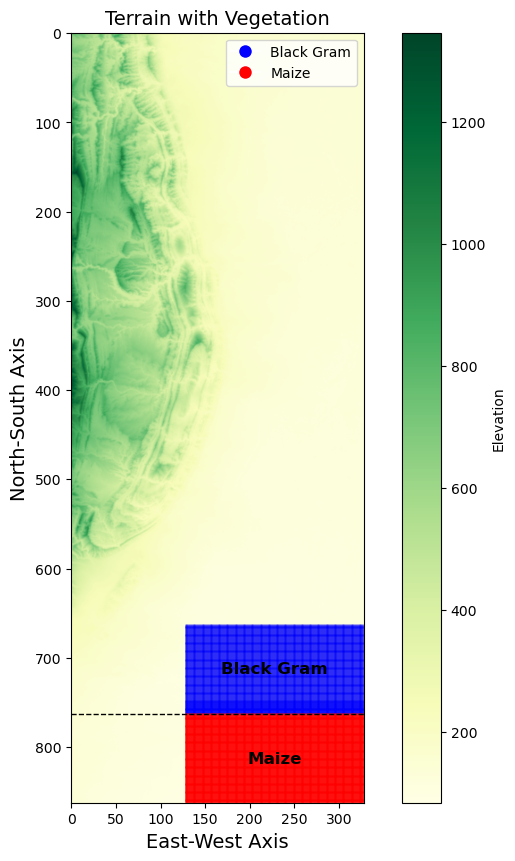

In [6]:
plt.figure(figsize=(10, 10))
plt.imshow(Terrain)
plt.xlabel('East-West Axis', fontsize=14)
plt.ylabel('North-South Axis', fontsize=14)
plt.title('Terrain with Vegetation', fontsize=14)
plt.set_cmap("YlGn")
plt.colorbar(label='Elevation')

# Plot vegetation in the southeast quadrant
for i in range(ny-200, ny):
    for j in range(nx-200, nx):
        if i < ny-100:  # Black Gram area (upper half of the southeast quadrant)
            if Vegetation[i, j] > 0:
                plt.plot(j, i, 'bo', ms=1, alpha=Vegetation[i, j])
        else:  # Maize area (lower half of the southeast quadrant)
            if Vegetation[i, j] > 0:
                plt.plot(j, i, 'ro', ms=1, alpha=Vegetation[i, j])

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Black Gram',
                          markerfacecolor='b', markersize=10),
                   Line2D([0], [0], marker='o', color='w', label='Maize',
                          markerfacecolor='r', markersize=10)]
plt.legend(handles=legend_elements, loc='upper right')

# Add text labels for crop areas
plt.text(nx - 100, ny - 150, 'Black Gram', color='black', fontsize=12, fontweight='bold', ha='center', va='center')
plt.text(nx - 100, ny - 50, 'Maize', color='black', fontsize=12, fontweight='bold', ha='center', va='center')

# Highlight crop areas
plt.axhline(y=ny-100, color='black', linestyle='--', linewidth=1)

plt.show()

In [7]:
#Calculate the water surface flow

import numpy as np

def calculate_flow(dem):
    rows, cols = dem.shape
    flow_direction = np.zeros((rows, cols), dtype=int)
    flow_slope = np.zeros((rows, cols), dtype=float)
    for i in range(1, rows - 1):
        for j in range(1, cols - 1):
            max_slope = 0
            direction = 0
            current_elevation = dem[i, j]
            for di, dj, d in [(-1, 0, 1), (1, 0, 1), (0, -1, 1), (0, 1, 1), (-1, -1, np.sqrt(2)), (-1, 1, np.sqrt(2)), (1, -1, np.sqrt(2)), (1, 1, np.sqrt(2))]:
                neighbor_elevation = dem[i + di, j + dj]
                slope = (current_elevation - neighbor_elevation) / d
                if slope > max_slope:
                    max_slope = slope
                    direction = (di + 1) * 3 + (dj + 1)
            flow_direction[i, j] = direction
            flow_slope[i, j] = max_slope
    return [flow_direction, flow_slope]

# Example DEM
dem = Terrain

result = calculate_flow(dem)
flow_direction = result[0]
slope = result[1]

print(slope[3][3])

23.770000000000095


In [58]:
min_temp = 0  # Minimum temperature in Celsius
max_temp = 35  # Maximum temperature in Celsius

# Example constant temperature in Celsius
actual_temperature = np.ones((ny, nx)) * 32  # Example constant temperature of 32°C

# Normalize the temperature between 0 and 1
normalized_temperature = (actual_temperature - min_temp) / (max_temp - min_temp)

def calculate_evapotranspiration(vegetation, temperature):
    # Example function: evapotranspiration rate increases with temperature and decreases with vegetation density
    # Vegetation and temperature are assumed to be normalized between 0 and 1
    base_et = 0.5  # base evapotranspiration rate
    et = base_et * (1 - vegetation) * temperature
    return et

In [59]:
drought_start_day = 2  # Start drought on day 3
drought_duration_days = 3  # Drought lasts for 3 days
drought_severity = 0.7  # Severity when drought is in effect

# Function to determine if it's currently a drought period
def is_drought_period(current_day):
    return drought_start_day <= current_day < (drought_start_day + drought_duration_days)

# Function to get current drought severity
def get_drought_severity(current_day):
    if is_drought_period(current_day):
        return drought_severity
    else:
        return 0  # No drought

In [67]:
def create_canal_system(terrain):
    canals = np.zeros((ny, nx), dtype=bool)
    for i in range(ny-200, ny):
        for j in range(nx-200, nx):  # Place a canal every 10 cells horizontally
            if(i%10==0 or j==326):   # And a vertical canal to connect to reservoir
                canals[i, j] = True
    return canals

canals = create_canal_system(Terrain)

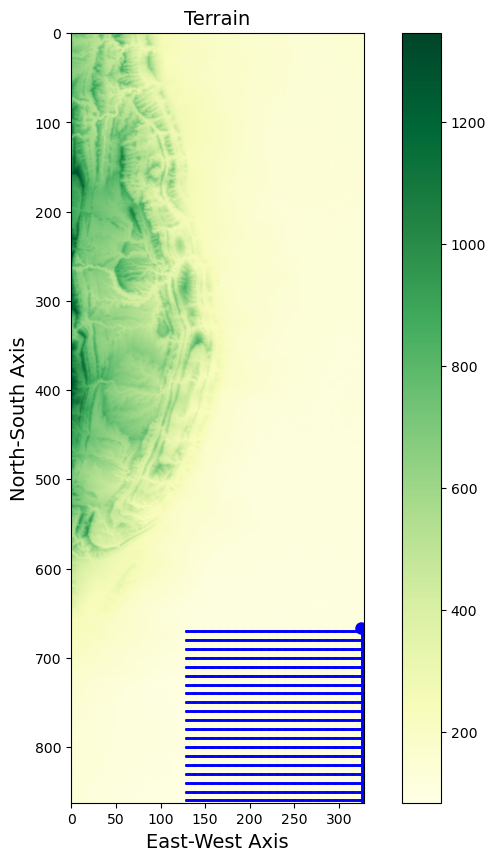

In [68]:
canal_x = []
canal_y = []

#plot the canals upon the terrain
plt.figure(figsize=(10, 10))
plt.imshow(Terrain)

plt.xlabel('East-West Axis', fontsize=14)
plt.ylabel('North-South Axis', fontsize=14)
plt.title('Terrain', fontsize=14);
plt.set_cmap("YlGn")
plt.colorbar()

for i in range(ny-200, ny):
    for j in range(nx-200, nx):  # Plot the canals
        if canals[i, j] == True:
            canal_x.append(j)
            canal_y.append(i)
            plt.plot(j, i,'bo', ms=1)

# Plot a reservoir
plt.plot(325, 667,'bo', ms=8)

plt.show()

In [69]:
import random

Precip = np.zeros([ny, nx], dtype = float)

def fill_precipitation_grid():
    #fill the Precipitation grid
    for i in range(0, nx): #march east to west
        for j in range(0, ny): #march south to north
            Precip[j][i] = (5 + random.random()*2)/(31*24) # convert annual amount of rain to hourly

fill_precipitation_grid()

# def calculate_growth_rate(water_table, precipitation, water_coefficient, precip_coefficient):
#     growth_rate = (water_table.mean() * water_coefficient) + (precipitation.mean() * precip_coefficient)
#     return growth_rate


Day: 1.0, Drought Severity: 0
Black Gram: 0.2117, Maize: 0.3221
Day: 2.0, Drought Severity: 0.7
Black Gram: 0.2121, Maize: 0.3230
Day: 3.0, Drought Severity: 0.7
Black Gram: 0.2127, Maize: 0.3237
Day: 4.0, Drought Severity: 0.7
Black Gram: 0.2132, Maize: 0.3247
Day: 5.0, Drought Severity: 0
Black Gram: 0.2136, Maize: 0.3252
Day: 6.0, Drought Severity: 0
Black Gram: 0.2142, Maize: 0.3260
Day: 7.0, Drought Severity: 0
Black Gram: 0.2150, Maize: 0.3268
Sim Run Time 133508.50512695312 milliseconds


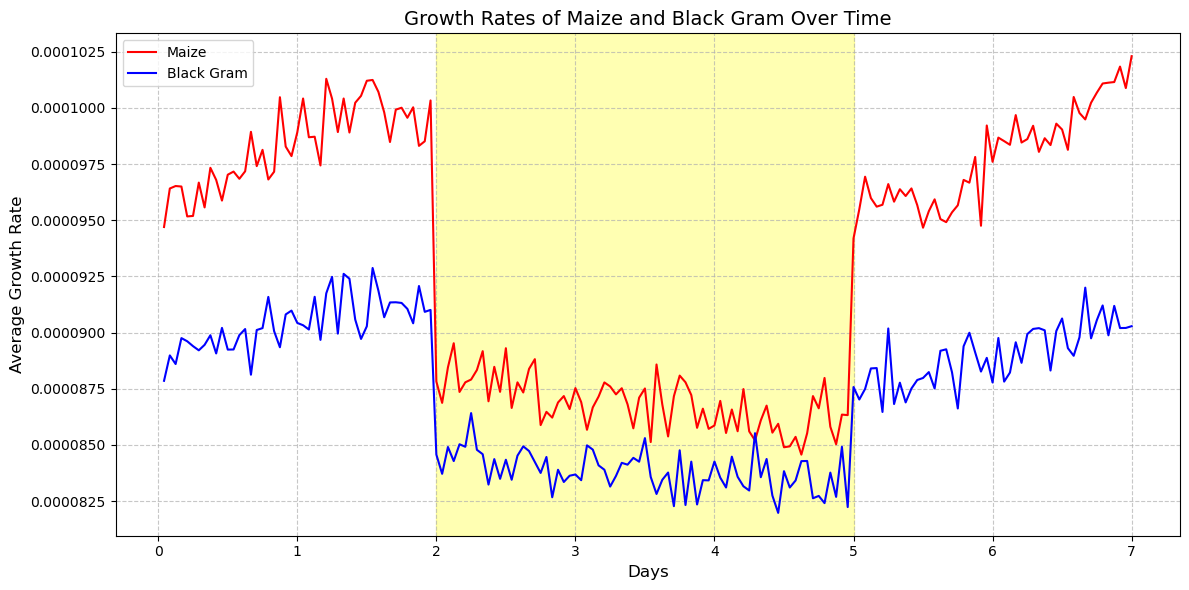

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time

# Define dimensions and parameters
ny, nx = 863, 328  # Adjust these to match your Terrain dimensions
ntimes = 7*24+1  # Number of time steps (seven days)
dt = 3600  # Time per time step (one hour)

# Define the southeast region
se_start_row = ny - 200
se_start_col = nx - 200
canal_flow = 2.855e10 # cm^3/second  #flow of river at start

#Define the Parameters (lengths all in cm)
L=390000;  # length of estuary in cm (3.9 kilometers) East-West Distance
h=350000;  # width of estuary in cm (3.5 kilometers)  North-South Distance
dx=10000;  # E-W grid spacing in cm (100 meters) East-West Spacing
dy=10000;  # N-S grid spacing in cm (100 meters) North-South Spacing

#Factors controlling water diffusion
Kh=2.895e-5; # TO RESEARCH: horizontal diffusivity (2.895 x 10^-5 cm^2/s)
Kv=2.895e-5; # TO RESEARCH: vertical diffusivity   (2.895 x 10^-5 cm^2/s)

ntimes=7*24+1; # number of time steps (seven days)
dt=3600;

# Set up water diffusion parameters
Kh = 2.895e-5  # Horizontal diffusivity
Kv = 2.895e-5  # Vertical diffusivity

# Set up drought parameters
drought_start_day = 2
drought_duration_days = 3
drought_severity = 0.7

def is_drought_period(current_day):
    return drought_start_day <= current_day < (drought_start_day + drought_duration_days)

def get_drought_severity(current_day):
    return drought_severity if is_drought_period(current_day) else 0

def water_diffusion(k, i, j):
    if i == 0 or i == ny-1 or j == 0 or j == nx-1:
        return W[i,j,k-1]  # No diffusion at edges
    
    result = W[i,j,k-1] + Kh*(dt/dx**2)*(W[i,j+1,k-1]-2*W[i,j,k-1]+W[i,j-1,k-1])
    result += Kv*(dt/dy**2)*(W[i+1,j,k-1]-2*W[i,j,k-1]+W[i-1,j,k-1])
    return result

def calculate_growth_rate(water_table, precipitation, crop_type, drought_severity, day):
    # Base rates
    base_rate = 0.025 if crop_type == 'maize' else 0.015
    
    # Water factor with more sensitivity
    water_factor = 2 / (1 + np.exp(-0.1 * water_table)) - 1  # Sigmoid function
    
    # Precipitation factor with diminishing returns
    precip_factor = np.log1p(precipitation) / np.log1p(1)  # Normalized log scale  -1 to 1
    
    # Drought effect with increasing severity
    drought_factor = 1 - (drought_severity ** 1.5)
    
    # Time-dependent factor (simulating seasonal effects)
    time_factor = 1 + 0.2 * np.sin(2 * np.pi * day / 7)  # Weekly cycle
    
    growth_rate = base_rate * water_factor * precip_factor * drought_factor * time_factor
    
    # Add some random variability
    variability = np.random.normal(0, 0.0002)  # Increased variability
    
    #Variability factors are: 
    # Temperature fluctuations
    # Soil nutrient levels
    # Pest presence
    # Daylight hours (seasonal effects)
    
    return max(0, growth_rate + variability)  # Ensure non-negative growth rate

# Initialize water array
W = np.zeros((ny, nx, ntimes))
W[:,:,0] = Winit

# Set whether W represents height or depth
W_is_height = True
maize_growth_rates = []
black_gram_growth_rates = []

# Main simulation loop
sim_start_time = time.time()*1000.0
for t in range(1, ntimes):
    current_day = t / 24
    current_drought_severity = get_drought_severity(current_day)
    maize_gr_sum = 0
    black_gram_gr_sum = 0
    maize_count = 0
    black_gram_count = 0
    for i in range(se_start_row, ny):
        for j in range(se_start_col, nx):
            W[i,j,t] = water_diffusion(t, i, j)
            
            # Canal water addition with boundary checks
            if canals[i, j]:
                W[i,j,t] += 0.01 if W_is_height else -0.01
            elif ((j > se_start_col and canals[i, j-1]) or 
                  (j < nx-1 and canals[i, j+1]) or 
                  (i > se_start_row and canals[i-1, j]) or 
                  (i < ny-1 and canals[i+1, j])):
                W[i,j,t] += 0.005 if W_is_height else -0.005
            
            # Evaporation and respiration
            evap_amount = (0.00001*255) * (1 - Vegetation[i,j]) if W[i,j,t] < Soil[i,j] else (0.0005*255) * (1 - Vegetation[i,j])
            resp_amount = (0.00008*255) * Vegetation[i,j]
            
            if W_is_height:
                W[i,j,t] -= evap_amount
                W[i,j,t] += resp_amount
            else:
                W[i,j,t] += evap_amount
                W[i,j,t] -= resp_amount

            # Precipitation
            rain_chance = 0.10 * (1 - current_drought_severity)
            if random.random() < rain_chance:
                p_rand = random.random() * 200 + 10
                rain_amount = Precip[i,j] / p_rand * (1 - current_drought_severity)
                if W_is_height:
                    W[i,j,t] += rain_amount
                else:
                    W[i,j,t] -= rain_amount
            
            # Vegetation update
            if i < se_start_row + 100:  # Black Gram area
                gr = calculate_growth_rate(W[i,j,t], Precip[i,j], 'black_gram', current_drought_severity, current_day)
                black_gram_gr_sum += gr
                black_gram_count += 1
            else:  # Maize area
                gr = calculate_growth_rate(W[i,j,t], Precip[i,j], 'maize', current_drought_severity, current_day)
                maize_gr_sum += gr
                maize_count += 1

            Vegetation[i,j] *= (1 + gr)
            Vegetation[i,j] = min(Vegetation[i,j], 1.0)     
            
            # Surface flow with boundary checks
            for direction in range(1, 9):
                di, dj = [(0,-1), (0,1), (-1,0), (1,0), (-1,-1), (-1,1), (1,-1), (1,1)][direction-1]
                ni, nj = i + di, j + dj
                if se_start_row <= ni < ny and se_start_col <= nj < nx:  # Check if neighbor is within bounds
                    if flow_direction[i,j] == direction and W[ni,nj,t] > Soil[ni,nj]:
                        flow_amount = (W[ni,nj,t] - Soil[ni,nj]) * slope[i,j] * 0.000001
                        if W_is_height:
                            W[i,j,t] += flow_amount
                        else:
                            W[i,j,t] -= flow_amount
            
            # Ensure water level stays within bounds
            if W[i,j,t] < 0:
                W[i,j,t] = 0
            elif W[i,j,t] > 100:
                W[i,j,t] = 100

    maize_avg_gr = maize_gr_sum / maize_count if maize_count > 0 else 0
    black_gram_avg_gr = black_gram_gr_sum / black_gram_count if black_gram_count > 0 else 0
    
    maize_growth_rates.append(maize_avg_gr)
    black_gram_growth_rates.append(black_gram_avg_gr)
    
    if t % 24 == 0:
        print(f"Day: {current_day}, Drought Severity: {current_drought_severity}")
        print(f"Black Gram: {Vegetation[se_start_row+50, se_start_col+50]:.4f}, Maize: {Vegetation[ny-50, nx-50]:.4f}")

print("Sim Run Time", str(time.time()*1000.0 - sim_start_time), "milliseconds")        

import matplotlib.pyplot as plt

# Create time axis (in days)
days = [i/24 for i in range(1, ntimes)]

# Create the line graph
plt.figure(figsize=(12, 6))
plt.plot(days, maize_growth_rates, label='Maize', color='red')
plt.plot(days, black_gram_growth_rates, label='Black Gram', color='blue')

plt.xlabel('Days', fontsize=12)
plt.ylabel('Average Growth Rate', fontsize=12)
plt.title('Growth Rates of Maize and Black Gram Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the drought period
drought_start = drought_start_day
drought_end = drought_start_day + drought_duration_days
plt.axvspan(drought_start, drought_end, color='yellow', alpha=0.3, label='Drought Period')

plt.tight_layout()
plt.show()

In [17]:
# # For later use: process canal channel flow (for any terrain slope):
# flow_in = 0
# for w in range(0, len(canal_x)): #calculate water contribution to river channel
#     flow_in = flow_in + (W[canal_x[w],canal_y[w],t]/len(canal_x))
#     p_avg = 0
#     if(t>100):
#         for m in range(0, 100):
#             p_avg = (p_avg + P[t-m])/100
#     if(p_avg > 0):  # direct moving_average contribution from rain
#         flow_in = flow_in + p_avg
# canal_flow = flow_in
# F.append(canal_flow)

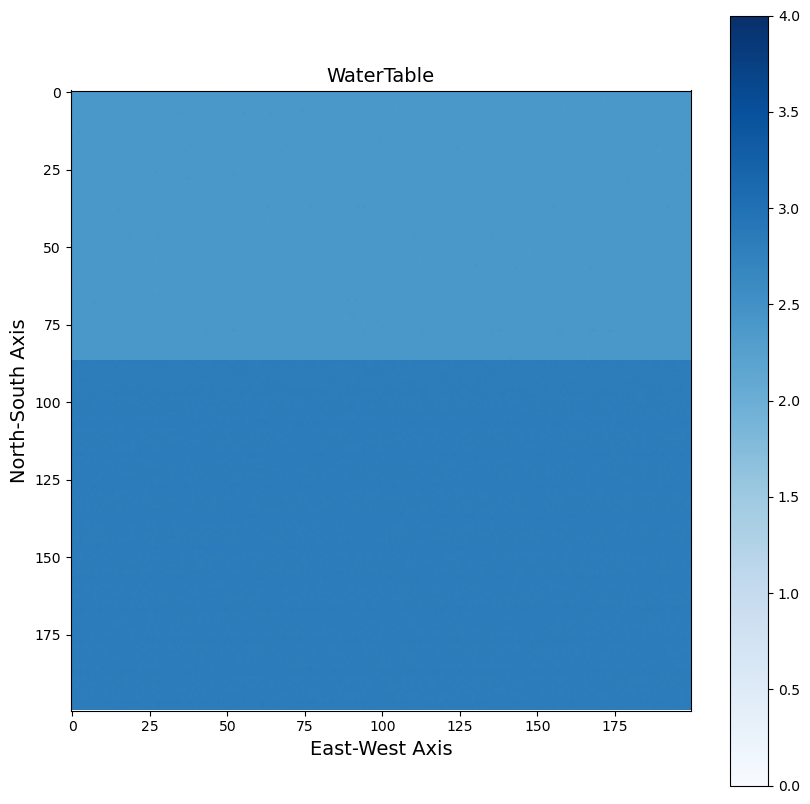

In [73]:
# plot the water level for just the crops region

def plot_water_table(timestep):
    crops_wtable = []
    
    for i in range(se_start_row, ny):
        row = []
        for j in range(se_start_col, nx):
            row.append(W[i][j][timestep])
        crops_wtable.append(row)
    
    #plot vegetation cover
    plt.figure(figsize=(10, 10))
    plt.imshow(crops_wtable, vmin=0, vmax=4)

    plt.xlabel('East-West Axis', fontsize=14)
    plt.ylabel('North-South Axis', fontsize=14)
    plt.title('WaterTable', fontsize=14);
    plt.set_cmap("Blues")
    plt.colorbar()
    
    plt.show()
        
plot_water_table(7*24)

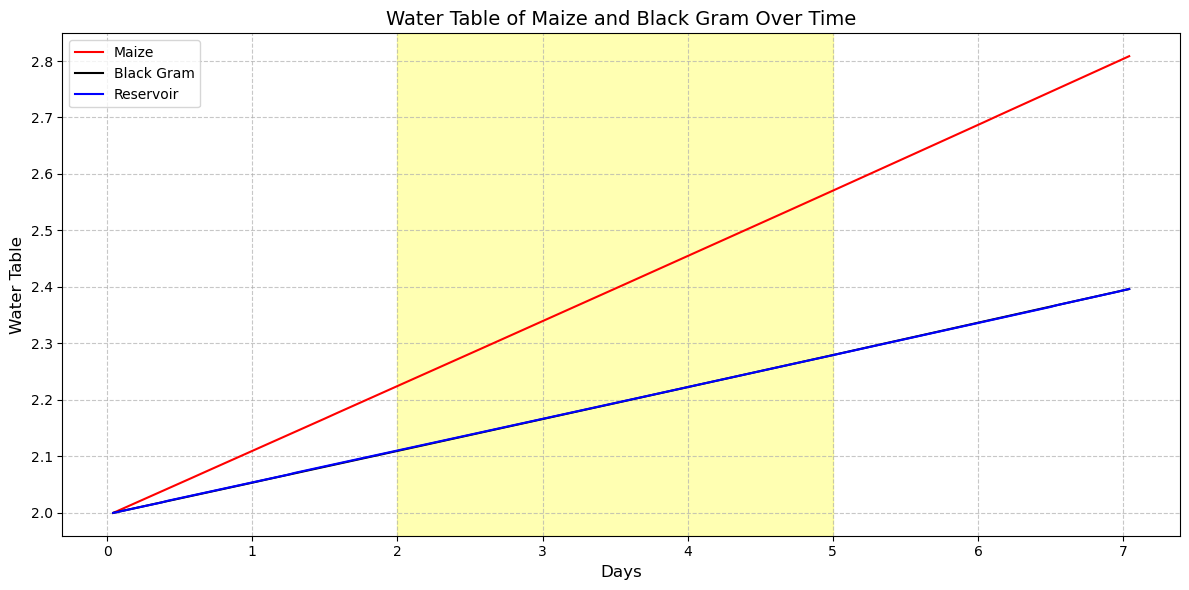

In [74]:
###### Show water table evolution at a points near middle of Maize and Black Gram fields

import matplotlib.pyplot as plt

days = [i/24 for i in range(1, ntimes+1)]

# Create the line graph
plt.figure(figsize=(12, 6))
plt.plot(days, W[825][225], label='Maize', color='red')
plt.plot(days, W[725][225], label='Black Gram', color='black')
plt.plot(days, W[667][325], label='Reservoir', color='blue')

plt.xlabel('Days', fontsize=12)
plt.ylabel('Water Table', fontsize=12)
plt.title('Water Table of Maize and Black Gram Over Time', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Highlight the drought period
drought_start = drought_start_day
drought_end = drought_start_day + drought_duration_days
plt.axvspan(drought_start, drought_end, color='yellow', alpha=0.3, label='Drought Period')

plt.tight_layout()
plt.show()